# Terrasses parisiennes et signalements citoyens : existe-t-il un lien ?

## Contexte et objectif

La Ville de Paris autorise l'installation de terrasses commerciales sur l'espace public.
Ces installations occupent la voie publique et sont susceptibles d'etre associees a des
nuisances (occupation abusive, proprete, bruit...) que les riverains peuvent signaler via
l'application Dans Ma Rue.

**Hypothese de depart** : existe-t-il une relation mesurable entre la presence, la
nature ou la densite des terrasses et les signalements d'anomalies sur l'espace public
environnant ?

Cette question generale est declinee en quatre hypotheses testables, traitees une a une
dans ce notebook.

## Sources de donnees

| Jeu de donnees | Lignes | Role |
|---|---|---|
| `terrasses-autorisations` (Open Data Paris) | 24 207 | Autorisations de terrasses |
| `dans-ma-rue` (Open Data Paris) | 1 474 285 | Signalements citoyens |
| `quartier_paris` (Open Data Paris) | 80 | Referentiel geographique (surface par quartier) |

L'extraction des donnees (`extraction/extract.py`) et l'exploration initiale de chaque
source sont detaillees dans `01_exploration_terrasses.ipynb` et
`02_exploration_dans_ma_rue.ipynb`.

## 1. Preparation des donnees

In [1]:
import re
import unicodedata

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import statsmodels.api as sm

terrasses = pd.read_csv("../data/terrasses-autorisations.csv", sep=";")
signalements = pd.read_csv("../data/dans-ma-rue.csv", sep=";")

### Harmonisation du champ arrondissement

`terrasses` encode l'arrondissement comme un code postal (`75015`), `signalements`
utilise le numero brut (`15`). Les deux representent la meme information sous deux
conventions differentes — sans cette conversion, une comparaison entre les deux colonnes
echouerait systematiquement (verifie : 100 % d'incoherence avant correction, contre 3,5 %
apres, un niveau credible pour de vraies donnees).

In [2]:
terrasses['arrondissement'] = (terrasses['arrondissement'] % 100).astype('Int64')

# Quelques codes d'arrondissement invalides existent dans signalements (0, 44, 82 --
# Paris n'a que 20 arrondissements), en quantite negligeable (109 lignes sur 1.47M).
signalements = signalements[signalements['arrondissement'].between(1, 20)]

### Normalisation des adresses

Les deux jeux de donnees n'utilisent pas le meme format d'adresse : `terrasses` est en
majuscules sans accents, `signalements` est geocode avec une casse mixte, des accents,
et un suffixe code postal + ville. Sans normalisation, une jointure textuelle echouerait
presque systematiquement.

In [3]:
def normaliser_adresse(adresse):
    if pd.isna(adresse):
        return adresse
    adresse = adresse.split(',')[0]  # retire ", 75XXX PARIS"
    adresse = adresse.upper().strip()
    adresse = ''.join(
        c for c in unicodedata.normalize('NFKD', adresse) if not unicodedata.combining(c)
    )
    return re.sub(r'\s+', ' ', adresse)


terrasses['adresse'] = terrasses['adresse'].apply(normaliser_adresse)
signalements['adresse'] = signalements['adresse'].apply(normaliser_adresse)

adresses_terrasses = set(terrasses['adresse'].dropna().unique())
adresses_signalements = set(signalements['adresse'].dropna().unique())
communes = adresses_terrasses & adresses_signalements

print(f"Adresses uniques (terrasses)     : {len(adresses_terrasses)}")
print(f"Adresses communes                : {len(communes)}")
print(f"Taux de recouvrement             : {len(communes) / len(adresses_terrasses):.1%}")

Adresses uniques (terrasses)     : 14862
Adresses communes                : 12021
Taux de recouvrement             : 80.9%


80,9 % des adresses de terrasses trouvent une correspondance exacte cote signalements —
suffisant pour une jointure fiable. Les 19 % restants (variantes de graphie non couvertes
par la normalisation) constituent une limite documentee du projet (section finale).

## 2. Ambiguite d'attribution : adresses a plusieurs terrasses

Certaines adresses comportent plusieurs terrasses distinctes. Dans ce cas, un
signalement a cette adresse ne peut pas etre attribue sans ambiguite a l'une ou l'autre.

Sur les 14 862 adresses de terrasses, 5 770 (38,8 %) sont dans ce cas ; 9 092 (61,2 %)
n'ont qu'une seule terrasse.

Pour les hypotheses necessitant une attribution precise (H2), l'analyse est restreinte
a ces 9 092 adresses non ambigues. Pour les hypotheses qui ne necessitent que de savoir
si une terrasse est presente (H1) ou de compter les terrasses par zone (H1-bis),
l'ensemble des terrasses est utilise sans restriction.

In [4]:
terrasses_par_adresse = terrasses.groupby('adresse').size()
adresses_non_ambigues = terrasses_par_adresse[terrasses_par_adresse == 1].index

terrasses_uniques = terrasses[terrasses['adresse'].isin(adresses_non_ambigues)]
jointure = terrasses_uniques.merge(
    signalements, on='adresse', how='inner', suffixes=('_terrasse', '_signalement')
)
jointure.shape

(94785, 28)

## Hypothese 1 — La presence d'une terrasse est-elle associee a un profil de signalement different ?

**Question.** A proximite d'une terrasse, les signalements ont-ils une composition (par
type d'anomalie) differente de celle observee ailleurs ?

**Methode.** Tableau croise (type de signalement x presence d'une terrasse a proximite),
test du Khi2 (existence d'un lien) puis V de Cramer (force du lien, independante de la
taille de l'echantillon — necessaire car un p-value seul devient quasi toujours
significatif avec un aussi grand echantillon).

In [5]:
signalements['a_une_terrasse'] = signalements['adresse'].isin(adresses_terrasses)

contingence_h1 = pd.crosstab(signalements['a_une_terrasse'], signalements['type'])

chi2_h1, p_h1, _, _ = chi2_contingency(contingence_h1)
n_h1 = contingence_h1.sum().sum()
r_h1, c_h1 = contingence_h1.shape
cramers_v_h1 = (chi2_h1 / (n_h1 * min(r_h1 - 1, c_h1 - 1))) ** 0.5

print(f"p-value      : {p_h1}")
print(f"V de Cramer  : {cramers_v_h1:.3f}")

p-value      : 0.0
V de Cramer  : 0.157


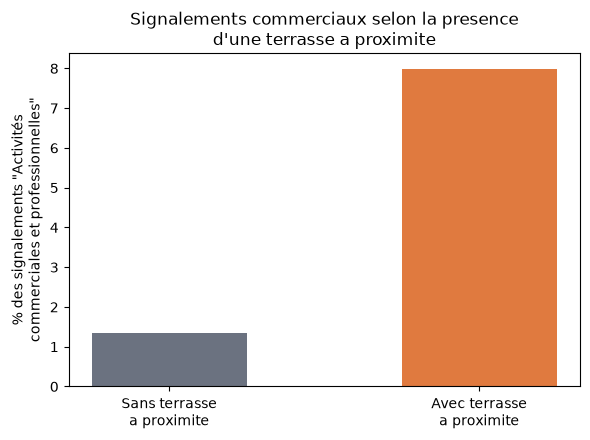

In [6]:
import matplotlib.pyplot as plt

parts_h1 = contingence_h1.div(contingence_h1.sum(axis=1), axis=0) * 100
valeurs_h1 = parts_h1['Activités commerciales et professionnelles']

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(
    ['Sans terrasse\na proximite', 'Avec terrasse\na proximite'],
    [valeurs_h1[False], valeurs_h1[True]],
    color=['#6b7280', '#e07a3f'],
    width=0.5,
)
ax.set_ylabel('% des signalements "Activités\ncommerciales et professionnelles"')
ax.set_title("Signalements commerciaux selon la presence\nd'une terrasse a proximite")
plt.tight_layout()
plt.show()

**Resultat.** Association statistiquement significative mais faible (V = 0,157). La
categorie qui porte l'essentiel de cet ecart est *Activités commerciales et
professionnelles* : 1,35 % des signalements sans terrasse a proximite contre 7,98 % avec
— un facteur 6, coherent avec le fait qu'une terrasse est elle-meme une activite
commerciale installee sur l'espace public.

**H1 : soutenue** — association statistiquement significative, mais faible.

## Hypothese 2 — La typologie de la terrasse influence-t-elle le type de signalement ?

**Question.** Parmi les terrasses, celles de typologie differente (terrasse fermee,
ouverte, etalage, contre-terrasse...) generent-elles des profils de signalement
differents ?

**Methode.** Meme principe que H1 (crosstab + Khi2 + V de Cramer), restreint aux 9 092
adresses non ambigues (`jointure`), croisant `typologie` (terrasse) avec `type`
(signalement).

In [7]:
contingence_h2 = pd.crosstab(jointure['typologie'], jointure['type'])

chi2_h2, p_h2, _, _ = chi2_contingency(contingence_h2)
n_h2 = contingence_h2.sum().sum()
r_h2, c_h2 = contingence_h2.shape
cramers_v_h2 = (chi2_h2 / (n_h2 * min(r_h2 - 1, c_h2 - 1))) ** 0.5

print(f"n = {n_h2}, p-value = {p_h2}")
print(f"V de Cramer : {cramers_v_h2:.3f}")

n = 94774, p-value = 0.0
V de Cramer : 0.075


**Resultat.** V = 0,075, sous le seuil de 0,1 — association negligeable en pratique,
malgre un p-value nul (attendu avec un echantillon de cette taille : le test devient tres
sensible au moindre ecart, meme sans interet pratique). La typologie de terrasse
n'apporte pas d'information exploitable sur le type de signalement attendu a proximite.

*Note de qualite de donnees : le champ `typologie` comporte quelques doublons de graphie
(ex. `TERRASSE FERMEE` sans accent et `TERRASSE FERMEE` avec accent), non corriges ici —
sans impact sur la conclusion vu le resultat deja negligeable.*

**H2 : non soutenue** — association negligeable (V = 0,075).

## Hypothese complementaire (H1-bis) — La densite de terrasses par arrondissement est-elle associee au volume de signalements commerciaux ?

H1 montre un lien entre presence de terrasse et signalements lies aux activites
commerciales, mais uniquement en presence/absence (binaire). Cette hypothese
complementaire teste un effet de gradient : les arrondissements a forte concentration de
terrasses ont-ils, proportionnellement a leur taille, davantage de signalements de ce
type ?

**Methode.** Agregation par arrondissement (20 zones), densite de terrasses et de
signalements commerciaux rapportee a la surface (source : `quartier_paris`, agregee par
arrondissement).

In [8]:
import geopandas as gpd

terrasses_par_arr = terrasses.groupby('arrondissement').size().rename('nb_terrasses')
signalements_par_arr = signalements.groupby('arrondissement').size().rename('nb_signalements')
commerciaux_par_arr = (
    signalements[signalements['type'] == 'Activités commerciales et professionnelles']
    .groupby('arrondissement').size().rename('nb_commerciaux')
)

quartiers = gpd.read_file("../data/quartier_paris.geojson")
surface_par_arr_km2 = (quartiers.groupby('c_ar')['surface'].sum() / 1_000_000).rename('surface_arr_km2')
surface_par_arr_km2.index = surface_par_arr_km2.index.astype('Int64')

zones = pd.concat(
    [terrasses_par_arr, signalements_par_arr, commerciaux_par_arr, surface_par_arr_km2],
    axis=1,
)
zones['densite_terrasses_km2'] = zones['nb_terrasses'] / zones['surface_arr_km2']
zones['taux_commerciaux_km2'] = zones['nb_commerciaux'] / zones['surface_arr_km2']
zones

,nb_terrasses,nb_signalements,nb_commerciaux,surface_arr_km2,densite_terrasses_km2,taux_commerciaux_km2
1,847,23680,1277,1.824613,464.208094,699.874541
2,672,24986,1610,0.991154,677.997726,1624.369553
3,568,52893,1537,1.170883,485.104059,1312.684751
4,890,46020,1212,1.600586,556.046467,757.222829
5,1275,32249,615,2.539374,502.092164,242.185632
6,761,21623,1021,2.153096,353.444544,474.200893
7,696,22705,495,4.090057,170.168767,121.025201
8,1180,37317,768,3.880037,304.120845,197.936279
9,1351,61152,2770,2.178303,620.207499,1271.631956
10,1682,105243,1918,2.891739,581.656822,663.268600


### Point de vigilance : correlation fallacieuse par denominateur partage

Une premiere comparaison entre `densite_terrasses_km2` et `taux_commerciaux_km2` (deux
variables divisees par la meme surface) donne une correlation tres forte (Spearman
rho = 0,89). Ce resultat est trompeur : diviser deux quantites par un meme denominateur
qui varie fortement (la surface varie d'un facteur 17 entre arrondissements, notamment a
cause du Bois de Vincennes et du Bois de Boulogne) peut generer une correlation
artificielle meme si les numerateurs sont independants (correlation fallacieuse des
ratios, Pearson 1897).

Deux verifications independantes de ce biais ont donc ete menees.

In [9]:
# Verification 1 : ratio sans denominateur partage (nb_terrasses n'apparait qu'une
# fois, en numerateur d'un cote et en denominateur de l'autre -- un artefact mecanique
# pur pousserait vers une correlation NEGATIVE, pas positive)
zones['commerciaux_par_terrasse'] = zones['nb_commerciaux'] / zones['nb_terrasses']

rho, p_rho = spearmanr(zones['densite_terrasses_km2'], zones['commerciaux_par_terrasse'])
r, p_r = pearsonr(zones['densite_terrasses_km2'], zones['commerciaux_par_terrasse'])
print(f"Spearman : {rho:.3f} (p={p_rho:.4f})")
print(f"Pearson  : {r:.3f} (p={p_r:.4f})")

Spearman : 0.544 (p=0.0131)
Pearson  : 0.528 (p=0.0168)


In [11]:
# Verification 2 : regression avec la surface comme covariable -- le nombre de
# terrasses explique-t-il le nombre de signalements commerciaux une fois l'effet de
# la surface neutralise ?
X = sm.add_constant(zones[['nb_terrasses', 'surface_arr_km2']])
y = zones['nb_commerciaux']
modele = sm.OLS(y, X).fit()
print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:         nb_commerciaux   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     4.239
Date:                Tue, 25 Aug 2026   Prob (F-statistic):             0.0321
Time:                        13:34:14   Log-Likelihood:                -164.38
No. Observations:                  20   AIC:                             334.8
Df Residuals:                      17   BIC:                             337.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -110.5085    773.956     

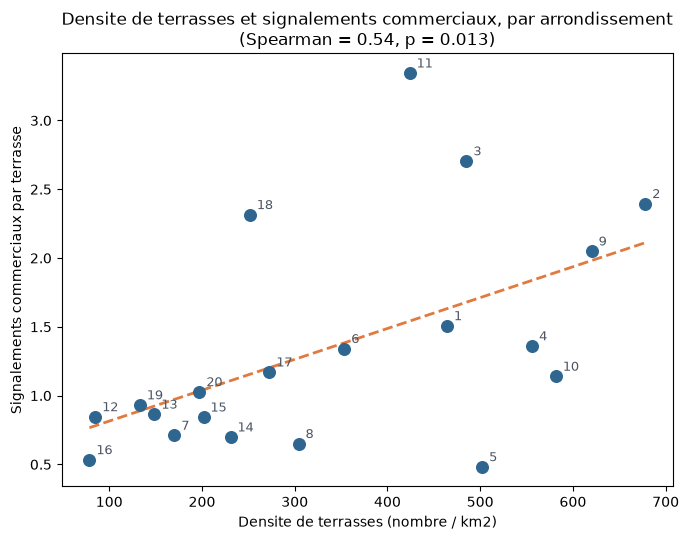

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(zones['densite_terrasses_km2'], zones['commerciaux_par_terrasse'], color='#2f6690', s=70, zorder=3)

coeffs = np.polyfit(zones['densite_terrasses_km2'], zones['commerciaux_par_terrasse'], 1)
x_ligne = np.linspace(zones['densite_terrasses_km2'].min(), zones['densite_terrasses_km2'].max(), 100)
ax.plot(x_ligne, coeffs[0] * x_ligne + coeffs[1], color='#e07a3f', linestyle='--', linewidth=2, zorder=2)

for arr, row in zones.iterrows():
    ax.annotate(str(arr), (row['densite_terrasses_km2'], row['commerciaux_par_terrasse']),
                textcoords='offset points', xytext=(5, 4), fontsize=9, color='#4b5563')

ax.set_xlabel('Densite de terrasses (nombre / km2)')
ax.set_ylabel('Signalements commerciaux par terrasse')
ax.set_title('Densite de terrasses et signalements commerciaux, par arrondissement\n(Spearman = 0.54, p = 0.013)')
plt.tight_layout()
plt.show()

**Resultat.** Les deux verifications confirment un signal positif et significatif
(rho = 0,544 ; coefficient `nb_terrasses` = 1,90, p = 0,013 meme apres ajustement pour
la surface, avec une correlation faible entre les deux predicteurs — r = 0,38, pas de
veritable colinearite), mais nettement plus modeste que la premiere estimation biaisee.

Une regression binomiale negative — mieux adaptee a une variable de comptage que l'OLS —
a egalement ete testee, mais n'a pas converge avec seulement 20 observations pour 4
parametres a estimer ; ce point est documente comme une limite plutot que traite comme
un resultat exploitable.

**H1-bis : signal positif modere, dont la robustesse varie selon le modele utilise.**
Association mesuree au niveau des arrondissements (association ecologique) — ne permet
pas de conclure au niveau d'une terrasse individuelle, ni a une relation causale.

## Comparaison visuelle des associations testees

Les V de Cramer de H1 et H2 se comparent directement (meme mesure, meme echelle 0-1) et
resument bien l'ecart entre les deux resultats.

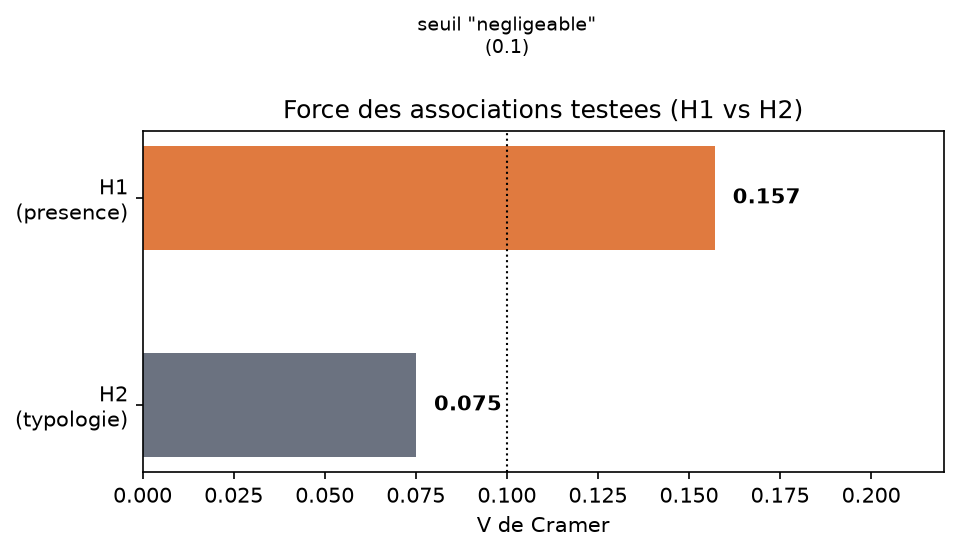

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
hypotheses = ['H2\n(typologie)', 'H1\n(presence)']
valeurs_v = [cramers_v_h2, cramers_v_h1]
couleurs_v = ['#6b7280', '#e07a3f']

ax.barh(hypotheses, valeurs_v, color=couleurs_v, height=0.5)
ax.axvline(0.1, color='black', linestyle=':', linewidth=1)
ax.text(0.1, 1.7, 'seuil "negligeable"\n(0.1)', fontsize=9, ha='center')
for i, v in enumerate(valeurs_v):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontweight='bold')
ax.set_xlabel('V de Cramer')
ax.set_title('Force des associations testees (H1 vs H2)')
ax.set_xlim(0, 0.22)
plt.tight_layout()
plt.show()

## Hypothese 3 — La periode d'installation saisonniere influence-t-elle le moment des signalements ?

**Question.** Un signalement lie a une terrasse saisonniere (installee seulement une
partie de l'annee) survient-il plus souvent pendant sa periode d'activite que ne le
voudrait le hasard ?

**Methode.** Seules les terrasses avec une periode saisonniere reellement definie sont
concernees (ni valeur manquante, ni "Toute l'année" — un cas ambigu, `du 31/12 au
30/12`, est egalement exclu par prudence). Pour chaque signalement, on calcule la
probabilite qu'il tombe "par hasard" dans la periode active de sa terrasse (longueur de
la periode / 12), puis on compare le nombre observe de signalements "dans la periode" au
nombre attendu sous cette hypothese de hasard. Les probabilites variant d'une terrasse a
l'autre, la somme suit une loi de Poisson-binomiale plutot qu'une binomiale classique —
la comparaison est donc faite par simulation Monte Carlo plutot que par un test
parametrique classique.

In [ ]:
h3 = jointure[
    jointure['periode_installation'].notna()
    & (jointure['periode_installation'] != "Toute l'année")
    & (jointure['periode_installation'] != 'du 31/12 Au 30/12')
].copy()


def parse_periode(periode):
    debut_jour, debut_mois, fin_jour, fin_mois = re.match(
        r"du (\d+)/(\d+) [Aa]u (\d+)/(\d+)", periode
    ).groups()
    return int(debut_mois), int(fin_mois)


def dans_periode(debut, fin, mois):
    return (debut <= mois <= fin) if debut <= fin else (mois >= debut or mois <= fin)


def longueur_periode(debut, fin):
    return (fin - debut + 1) if debut <= fin else (12 - debut + 1) + fin


h3[['mois_debut', 'mois_fin']] = h3['periode_installation'].apply(
    lambda p: pd.Series(parse_periode(p))
)
h3['dans_periode'] = h3.apply(
    lambda r: dans_periode(r['mois_debut'], r['mois_fin'], r['moisdecl']), axis=1
)
h3['probabilite_hasard'] = h3.apply(
    lambda r: longueur_periode(r['mois_debut'], r['mois_fin']) / 12, axis=1
)

np.random.seed(42)
p = h3['probabilite_hasard'].values
observe = h3['dans_periode'].sum()
attendu = p.sum()

simulations = np.random.binomial(1, p, size=(100_000, len(p))).sum(axis=1)
p_value = np.mean(np.abs(simulations - attendu) >= np.abs(observe - attendu))

print(f"n = {len(h3)}")
print(f"Observe : {observe}, attendu : {attendu:.2f}")
print(f"p-value (Monte Carlo) : {p_value:.4f}")

n = 20
Observe : 13, attendu : 10.75
p-value (Monte Carlo) : 0.3725


NameError: name 'attendu' is not defined

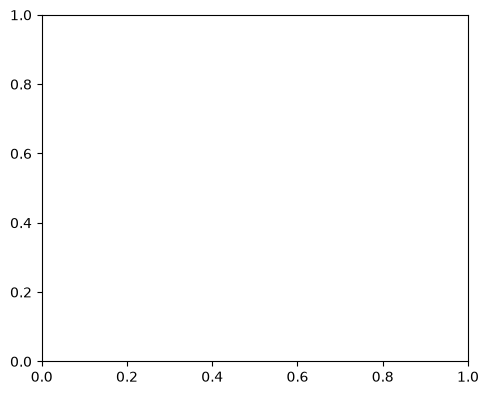

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.bar(['Attendu\n(sous H0)', 'Observe'], [attendu, observe], color=['#6b7280', '#2f6690'], width=0.5)
for i, v in enumerate([attendu, observe]):
    ax.text(i, v + 0.2, f"{v:.2f}" if v == attendu else str(int(v)), ha='center', fontweight='bold')
ax.set_ylabel('Nombre de signalements dans la periode active')
ax.set_title(f'Signalements observes vs attendus par hasard\n(p = {p_value:.2f}, non significatif)')
plt.tight_layout()
plt.show()

**Resultat.** La direction observee va dans le sens de l'hypothese (13 signalements
observes dans la periode active contre 10,75 attendus par hasard), mais l'ecart n'est
pas statistiquement significatif (p = 0,37). Avec seulement 20 observations exploitables
— la tres grande majorite des terrasses n'ayant pas de periode saisonniere renseignee
dans les donnees sources —, le test manque de puissance statistique pour trancher.

**H3 : non concluante.** Absence de preuve d'un effet, ce qui est different d'une preuve
d'absence d'effet — limite de disponibilite de la donnee source, pas de la methode.

## Synthese

| Hypothese | Resultat |
|---|---|
| H1 — Presence d'une terrasse / type de signalement | Soutenue — association statistiquement significative, mais faible (V = 0,157) |
| H2 — Typologie de terrasse / type de signalement | Non soutenue — association negligeable (V = 0,075) |
| H1-bis — Densite de terrasses / signalements commerciaux (par arrondissement) | Signal positif modere, robustesse variable selon le modele |
| H3 — Saisonnalite / moment des signalements | Non concluante — puissance statistique insuffisante (n = 20) |

### Limites generales

- La jointure par adresse ne couvre que 80,9 % des terrasses ; les 19 % non appariees
  pourraient differer systematiquement des autres (biais non explore).
- Les analyses par zone (H1-bis) mesurent une association ecologique, au niveau des
  arrondissements — elles ne permettent pas de conclure a un effet au niveau d'une
  terrasse individuelle.
- Aucune des analyses ne permet d'etablir une relation causale : correlation observee,
  pas mecanisme demontre.
- Dans Ma Rue est un canal de signalement declaratif : une zone avec davantage de
  signalements peut refleter des riverains plus actifs sur l'application, pas
  necessairement davantage de problemes reels.
- Les echantillons agreges par arrondissement (H1-bis, H3) sont petits (n = 20), ce qui
  limite la puissance statistique des tests correspondants.

### Recommandations

1. **Prioriser les controles vers les zones a forte densite de terrasses** plutot qu'une
   repartition uniforme sur la ville (H1, H1-bis) — a valider avec des donnees plus
   fines (rue ou etablissement) avant d'en faire une regle operationnelle.
2. **Ne pas differencier les priorites d'inspection selon la typologie de terrasse** —
   cette variable n'apporte pas d'information exploitable sur le type de signalement a
   attendre (H2).
3. **Ameliorer la collecte du champ `periode_installation`** avant de pouvoir exploiter
   la saisonnalite dans une politique d'inspection (H3) — la donnee actuelle est trop
   incomplete pour trancher.